In [1]:
!pip install numpy matplotlib "pyvista[jupyter]"


[notice] A new release of pip is available: 26.0.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
import numpy as np
import matplotlib.pyplot as plt
import pyvista as pv
import logging
logging.getLogger("asyncio").setLevel(logging.CRITICAL)

In [4]:
## read 3d numpy arrays
data_vol = np.load('sedgwick_shrubs.npy')
topo = np.load('sedgwick_topo.npy')[0]
topo = np.round(topo).astype(np.int32)
max_offset = topo.max()

In [5]:
print(data_vol.shape)
print(topo.shape)

(2, 819, 383)
(819, 383)


## Visualize Fuels as 2D Slices

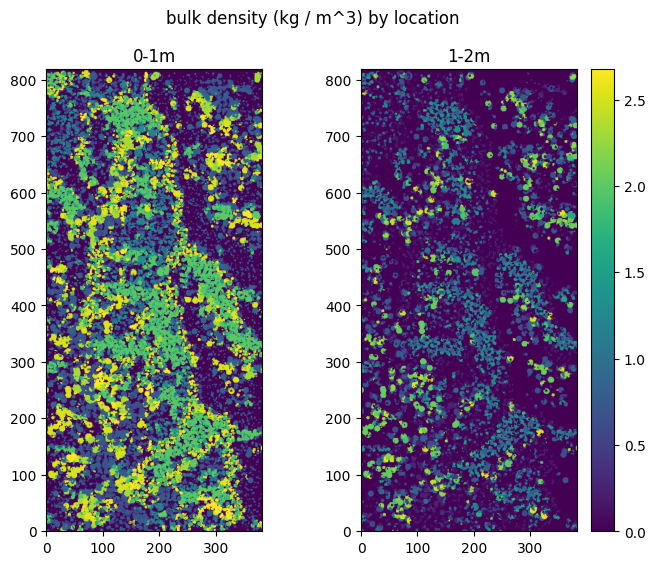

In [6]:
fig, ax = plt.subplots(1,2, figsize=(8,6))
fig.suptitle("bulk density (kg / m^3) by location")
ax[0].imshow(data_vol[0], origin="lower")
ax[0].set_title("0-1m")
res = ax[1].imshow(data_vol[1], origin="lower")
ax[1].set_title("1-2m")
plt.colorbar(res)

## 3D Visualization

In [13]:
z_coords, y_coords, x_coords = np.meshgrid(
    np.arange(data_vol.shape[0]),
    np.arange(data_vol.shape[1]),
    np.arange(data_vol.shape[2]),
    indexing="ij",
)

z_coords = z_coords + topo
points = np.c_[x_coords.ravel(), y_coords.ravel(), z_coords.ravel()]

grid = pv.StructuredGrid()
# Dimensions passed as (X, Y, Z) ordering for PyVista
grid.dimensions = (data_vol.shape[2], data_vol.shape[1], data_vol.shape[0])
grid.points = points
grid.point_data["values"] = data_vol.ravel()  # C-ordering works here with ravel
poly_data = grid.extract_surface()
pl = pv.Plotter()
pl.add_mesh(poly_data, cmap="viridis", scalars="values", show_edges=False)
pl.show()

C:\Users\isaac\AppData\Local\Temp\ipykernel_10780\1075307423.py:16: PyVistaFutureWarning: The default value of `algorithm` for the filter
`StructuredGrid.extract_surface` will change in the future. It currently defaults to
`'dataset_surface'`, but will change to `None`. Explicitly set the `algorithm` keyword to
silence this warning.
  poly_data = grid.extract_surface()


Widget(value='<iframe src="http://localhost:1056/index.html?ui=P_0x2aba6f31d10_4&reconnect=auto" class="pyvist…